In [1]:
import numpy as np

In [2]:
import jax
jax.config.update('jax_enable_x64', True)

jax.config.update('jax_enable_x64', True)
jax.config.update("jax_debug_nans", True)
jax.config.update("jax_debug_infs", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import jax.numpy.linalg as la


In [3]:
def skew(v):
		return jnp.array([[ 0., v[2], -v[1] ], [ -v[2], 0., v[0] ], [ v[1], -v[0], 0. ] ])

In [4]:
def get_u_v(Sdir):
    zdir = jnp.array([ 0., 0., 1. ])

    Sdir = Sdir / jnp.linalg.norm(Sdir)
    rotaxis = jnp.array([ 0., 1., 0. ])

    parallel = jnp.allclose(Sdir, zdir)
    antiparallel = jnp.allclose(Sdir, -zdir)

    def else_branch():
        rotaxis = jnp.cross(Sdir, zdir)
        s = jnp.linalg.norm(rotaxis)
        c = jnp.dot(Sdir, zdir)
        rotaxis = rotaxis / s
        return c, s, rotaxis

    def parallel_branch():
        return 1.0, 0.0, rotaxis

    def antiparallel_branch():
        return -1.0, 0.0, rotaxis

    # Use cond for three branches: first handle parallel, then antiparallel vs else
    c, s, rotaxis = jax.lax.cond(
        parallel,
        parallel_branch,
        lambda: jax.lax.cond(antiparallel, antiparallel_branch, else_branch),
    )
    # rotation via rodrigues' formula, see (Arens 2015), p. 718 and p. 816
    rot = (1. - c) * jnp.outer(rotaxis, rotaxis) + jnp.diag(jnp.array([ c, c, c ])) - skew(rotaxis)*s
    u, v = rot[0, :] + 1j * rot[1, :], rot[2, :]
    return u, v

def get_J_real(_J, _DMI, _gen):
    a = jnp.diag(jnp.ones(3)*_J)
    b = skew(_DMI)
    c = _gen
    return a + b + c


In [5]:
# from functools import partial

# def get_energies(Qvec, S_arr, u_arr, v_arr, pos_arr, J_real_arr, dist_arr, site1_arr, site2_arr):
#     N = len(S_arr)                      # number of sites
#     n_coup = len(J_real_arr)            # number of couplings

#     # ------------------------------------------------------------------
#     # 1. Fourier‑transformed exchange matrices J_fourier and J0_fourier
#     # ------------------------------------------------------------------
#     phase = jnp.exp(-2j * jnp.pi * jnp.dot(dist_arr, Qvec))   # (n_coup,)
#     J_ft = J_real_arr * phase[:, None, None]                  # (n_coup, 3, 3)

#     # Initialise
#     J_fourier = jnp.zeros((N, N, 3, 3), dtype=jnp.complex128)
#     J0_fourier = jnp.zeros((N, N, 3, 3), dtype=jnp.float64)

#     # Scatter‑add for (i,j) and (j,i)
#     J_fourier = J_fourier.at[site1_arr, site2_arr].add(J_ft)
#     J_fourier = J_fourier.at[site2_arr, site1_arr].add(jnp.conjugate(J_ft).transpose(0, 2, 1))

#     J0_fourier = J0_fourier.at[site1_arr, site2_arr].add(J_real_arr)
#     J0_fourier = J0_fourier.at[site2_arr, site1_arr].add(J_real_arr.transpose(0, 2, 1))

#     # ------------------------------------------------------------------
#     # 2. Build the 2N × 2N Hamiltonian H
#     # ------------------------------------------------------------------
#     # Pre‑compute factors
#     S_ij = 0.5 * jnp.sqrt(jnp.outer(S_arr, S_arr))            # (N, N) real
#     u = u_arr                                                 # (N, 3) complex
#     v = v_arr                                                 # (N, 3) complex

#     # Four blocks of H
#     H_00 = jnp.einsum('ia,ijab,jb->ij', u, J_fourier, u.conj()) * S_ij
#     H_01 = jnp.einsum('ia,ijab,jb->ij', u, J_fourier, u) * S_ij
#     H_10 = jnp.einsum('jb,jiba,ia->ij', u, J_fourier, u).conj() * S_ij
#     H_11 = jnp.einsum('ia,ijab,jb->ij', u.conj(), J_fourier, u) * S_ij

#     # Diagonal corrections
#     diag_corr = -jnp.einsum('j,ia,ijab,jb->i', S_arr, v, J0_fourier, v)
#     H_00 += jnp.diag(diag_corr)
#     H_11 += jnp.diag(diag_corr)

#     # Assemble full Hamiltonian
#     H = jnp.block([[H_00, H_01], [H_10, H_11]])               # (2N, 2N)

#     # ------------------------------------------------------------------
#     # 3. Cholesky, diagonalisation, and operator construction
#     # ------------------------------------------------------------------
#     # print(H + 1e-5*jnp.eye(H.shape[0], dtype=complex))
#     C = jnp.linalg.cholesky(H) # .real + 1e-5*jnp.eye(H.shape[0])) + 0j                                # lower triangular
#     signs_diag = jnp.concatenate([jnp.ones(N), -jnp.ones(N)])  # (2N,)
#     signs = jnp.diag(signs_diag)                              # (2N, 2N)

#     H_trafo = C.T.conj() @ signs @ C
#     Es_asc, states_asc = jnp.linalg.eigh(H_trafo)             # eigenvalues ascending
#     Es = Es_asc[::-1]                                         # descending
#     states = states_asc[:, ::-1]                              # eigenvectors in descending order

#     invC = jnp.linalg.inv(C)
#     sqrt_arg = signs_diag[:, None] * (states.T.conj() @ H_trafo @ states)  # element‑wise scaling
#     ops = invC.T.conj() @ states @ jnp.sqrt(sqrt_arg + 0j)         # (2N, 2N)


#     # ------------------------------------------------------------------
#     # 4. Build the M matrices for x,y = 0,1,2 and compute S_mats
#     # ------------------------------------------------------------------
#     # Phase factors for the structure factor
#     phase_factors = jnp.exp(2j * jnp.pi * (pos_arr @ Qvec))   # (N,)
#     phase_ij = jnp.outer(phase_factors.conj(), phase_factors) # (N, N)
#     S_ij_m = jnp.sqrt(jnp.outer(S_arr, S_arr))                # (N, N) no factor 0.5
#     u_scaled = -2.0 * u                                       # (N, 3)

#     # Initialise S_mats: (2N, 3, 3) complex
#     S_mats = jnp.zeros((2 * N, 3, 3), dtype=jnp.complex128)

#     for x in range(3):
#         ux = u_scaled[:, x]                                   # (N,)
#         for y in range(3):
#             uy = u_scaled[:, y]                               # (N,)

#             # Four blocks of M
#             M_00 = phase_ij * S_ij_m * jnp.outer(ux, uy.conj())
#             M_01 = phase_ij * S_ij_m * jnp.outer(ux, uy)
#             M_10 = phase_ij * S_ij_m * jnp.outer(ux.conj(), uy.conj())
#             M_11 = phase_ij * S_ij_m * jnp.outer(ux.conj(), uy)

#             M = jnp.block([[M_00, M_01], [M_10, M_11]])       # (2N, 2N)
#             M_transformed = ops.T.conj() @ M @ ops
#             diag = jnp.diag(M_transformed)                    # (2N,)
#             S_mats = S_mats.at[:, x, y].add(diag / (2.0 * N))

#     # ------------------------------------------------------------------
#     # 5. Compute weights from S_mats
#     # ------------------------------------------------------------------
#     proj = jnp.eye(3) - jnp.outer(Qvec, Qvec) / jnp.dot(Qvec, Qvec)   # (3, 3)
#     weights = jnp.abs(jnp.einsum('ij, eji->e', proj, S_mats).real)

#     return Es, weights

In [ ]:
from functools import partial

def get_energies(Qvec, S_arr, u_arr, v_arr, pos_arr, J_real_arr, dist_arr, site1_arr, site2_arr):
    N = len(S_arr)                      # number of sites
    n_coup = len(J_real_arr)            # number of couplings

    # ------------------------------------------------------------------
    # 1. Fourier‑transformed exchange matrices J_fourier and J0_fourier
    # ------------------------------------------------------------------
    phase = jnp.exp(-2j * jnp.pi * jnp.dot(dist_arr, Qvec))   # (n_coup,)
    J_ft = J_real_arr * phase[:, None, None]                  # (n_coup, 3, 3)

    # Initialise
    J_fourier = jnp.zeros((N, N, 3, 3), dtype=jnp.complex128)
    J0_fourier = jnp.zeros((N, N, 3, 3), dtype=jnp.float64)

    # Scatter‑add for (i,j) and (j,i)
    J_fourier = J_fourier.at[site1_arr, site2_arr].add(J_ft)
    J_fourier = J_fourier.at[site2_arr, site1_arr].add(jnp.conjugate(J_ft).transpose(0, 2, 1))

    J0_fourier = J0_fourier.at[site1_arr, site2_arr].add(J_real_arr)
    J0_fourier = J0_fourier.at[site2_arr, site1_arr].add(J_real_arr.transpose(0, 2, 1))

    # ------------------------------------------------------------------
    # 2. Build the 2N × 2N Hamiltonian H
    # ------------------------------------------------------------------
    # Pre‑compute factors
    S_ij = 0.5 * jnp.sqrt(jnp.outer(S_arr, S_arr))            # (N, N) real
    u = u_arr                                                 # (N, 3) complex
    v = v_arr                                                 # (N, 3) complex

    # Four blocks of H
    H_00 = jnp.einsum('ia,ijab,jb->ij', u, J_fourier, u.conj()) * S_ij
    H_01 = jnp.einsum('ia,ijab,jb->ij', u, J_fourier, u) * S_ij
    H_10 = jnp.einsum('jb,jiba,ia->ij', u, J_fourier, u).conj() * S_ij
    H_11 = jnp.einsum('ia,ijab,jb->ij', u.conj(), J_fourier, u) * S_ij

    # Diagonal corrections
    diag_corr = -jnp.einsum('j,ia,ijab,jb->i', S_arr, v, J0_fourier, v)
    H_00 += jnp.diag(diag_corr)
    H_11 += jnp.diag(diag_corr)

    # Assemble full Hamiltonian
    H = jnp.block([[H_00, H_01], [H_10, H_11]])               # (2N, 2N)

    # ------------------------------------------------------------------
    # 3. Cholesky, diagonalisation, and operator construction
    # ------------------------------------------------------------------
    C = jnp.linalg.cholesky(H)                                # lower triangular
    signs_diag = jnp.concatenate([jnp.ones(N), -jnp.ones(N)])  # (2N,)
    signs = jnp.diag(signs_diag)                              # (2N, 2N)

    H_trafo = C.T.conj() @ signs @ C
    Es_asc, states_asc = jnp.linalg.eigh(H_trafo)             # eigenvalues ascending
    Es = Es_asc[::-1]                                         # descending
    states = states_asc[:, ::-1]                              # eigenvectors in descending order

    # Diagonalize (ascending eigenvalues)
    eigenvals, eigenvecs = jax.scipy.linalg.eigh(H_trafo)

    # Make eigenvalues positive
    eigenvals_abs = jnp.maximum(jnp.abs(eigenvals), 1e-12)   # small epsilon for stability

    # Square root gives the bosonic frequencies
    sqrt_vals = jnp.sqrt(eigenvals_abs)

    # Construct the paraunitary matrix ops = invC^† * V * diag(sqrt(ω))
    invC = jnp.linalg.inv(C)        # or use solve_triangular for better stability
    ops = invC.T.conj() @ eigenvecs @ jnp.diag(sqrt_vals)

    # invC = jnp.linalg.inv(C)
    # sqrt_arg = signs_diag[:, None] * (states.T.conj() @ H_trafo @ states)  # element‑wise scaling
    # checkify.check(~jnp.any(jnp.isnan(sqrt_arg)), 'nans in sqrt arg')
    # ops = invC.T.conj() @ states @ jnp.sqrt(sqrt_arg)         # (2N, 2N)

    # ------------------------------------------------------------------
    # 4. Build the M matrices for x,y = 0,1,2 and compute S_mats
    # ------------------------------------------------------------------
    # Phase factors for the structure factor
    phase_factors = jnp.exp(2j * jnp.pi * (pos_arr @ Qvec))   # (N,)
    phase_ij = jnp.outer(phase_factors.conj(), phase_factors) # (N, N)
    S_ij_m = jnp.sqrt(jnp.outer(S_arr, S_arr))                # (N, N) no factor 0.5
    u_scaled = -2.0 * u                                       # (N, 3)

    # Initialise S_mats: (2N, 3, 3) complex
    S_mats = jnp.zeros((2 * N, 3, 3), dtype=jnp.complex128)

    for x in range(3):
        ux = u_scaled[:, x]                                   # (N,)
        for y in range(3):
            uy = u_scaled[:, y]                               # (N,)

            # Four blocks of M
            M_00 = phase_ij * S_ij_m * jnp.outer(ux, uy.conj())
            M_01 = phase_ij * S_ij_m * jnp.outer(ux, uy)
            M_10 = phase_ij * S_ij_m * jnp.outer(ux.conj(), uy.conj())
            M_11 = phase_ij * S_ij_m * jnp.outer(ux.conj(), uy)

            M = jnp.block([[M_00, M_01], [M_10, M_11]])       # (2N, 2N)
            M_transformed = ops.T.conj() @ M @ ops
            diag = jnp.diag(M_transformed)                    # (2N,)
            S_mats = S_mats.at[:, x, y].add(diag / (2.0 * N))

    # ------------------------------------------------------------------
    # 5. Compute weights from S_mats
    # ------------------------------------------------------------------
    proj = jnp.eye(3) - jnp.outer(Qvec, Qvec) / jnp.dot(Qvec, Qvec)   # (3, 3)
    weights = jnp.abs(jnp.einsum('ij, eji->e', proj, S_mats).real)

    return Es, weights

Calculating non-reciprocal ferromagnetic dispersion...
Plotting...


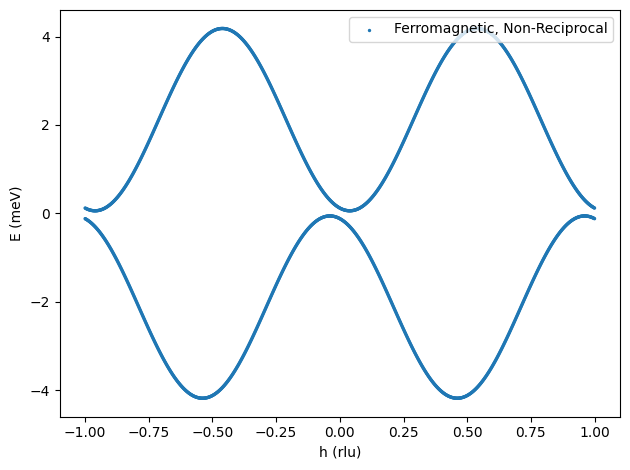

In [7]:
%run test_lswt_dmi.py

In [8]:
hs = np.array(hs)
Es = np.array(Es)
ws = np.array(ws)

In [9]:
num_Q_points = 1024
Q_pts = jnp.array([jnp.linspace(-1,1,num_Q_points), jnp.zeros(num_Q_points), jnp.zeros(num_Q_points)]).T

In [10]:
couplings, sites

([{'sites': [0, 0],
   'J': -1.0,
   'DMI': [0.0, 0.0, 0.25],
   'dist': [1, 0, 0],
   'J_real': array([[-1.  ,  0.25,  0.  ],
          [-0.25, -1.  ,  0.  ],
          [ 0.  ,  0.  , -1.  ]])},
  {'sites': [0, 0],
   'J': 0.0,
   'gen': array([[ 0.  ,  0.  ,  0.  ],
          [ 0.  ,  0.  ,  0.  ],
          [ 0.  ,  0.  , -0.06]]),
   'dist': [0, 0, 0],
   'J_real': array([[ 0.  ,  0.  ,  0.  ],
          [ 0.  ,  0.  ,  0.  ],
          [ 0.  ,  0.  , -0.06]])}],
 [{'S': 1.0,
   'Sdir': [0, 0, 1],
   'pos': [0, 0, 0],
   'u': array([1.+0.j, 0.+1.j, 0.+0.j]),
   'v': array([0., 0., 1.])}])

In [11]:
batched_by_q = jax.vmap(get_energies, (0, None, None, None, None, None, None, None, None))

# @jax.jit
def model(Q_vec, params):
    S_values = jnp.array([1.0])
    S_directions = jnp.array([[0, 0, 1]], dtype=float)
    positions = jnp.array([[0,0,0]], dtype=float)
    dist_vectors = jnp.array([[1,0,0], [0,0,0]], dtype=float)
    sites_i = jnp.array([0, 0])
    sites_j = jnp.array([0, 0])
    
    U, V = jax.vmap(get_u_v)(S_directions)
    
    J, DMI, SIA = params
    J_values = jnp.array([J, 0], dtype=float)
    DMI_vectors = jnp.array([[0,0,DMI], [0,0,0]], dtype=float)
    gen_matrices = jnp.array([
        [
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
        [
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, SIA],
        ]
    ], dtype=float)
    J_real = jax.vmap(get_J_real)(J_values, DMI_vectors, gen_matrices)


    (E, w) = batched_by_q(Q_vec, S_values, U, V, positions, J_real, dist_vectors, sites_i, sites_j)
    # err.throw()
    
    return E, w

In [12]:
E, w = model(Q_pts, jnp.array([-1, 0.25, -0.06]))
assert ~jnp.isnan(E).any()
assert ~jnp.isnan(w).any()


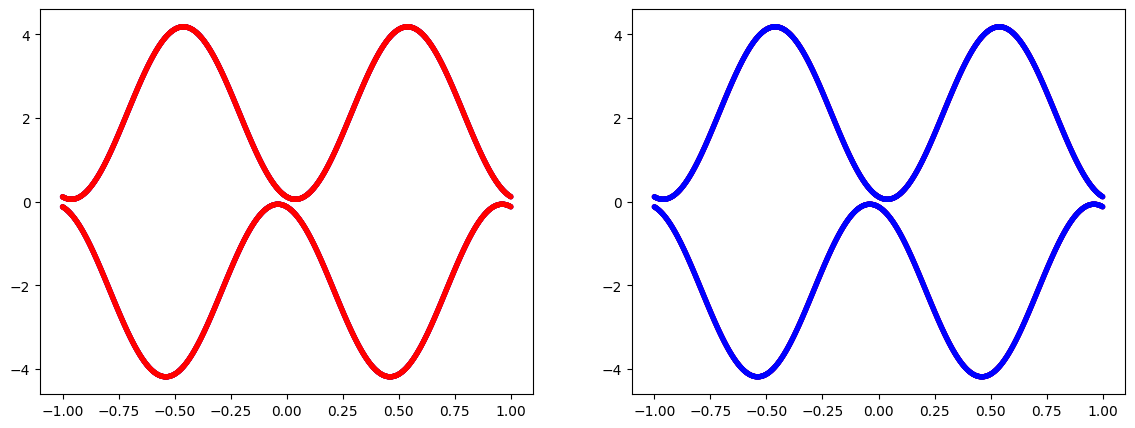

In [13]:
plt.subplots(1, 2, figsize=(14,5))
plt.subplot(121)
plt.scatter(hs, Es, ws, color='blue')
for _e, _w in zip(E.T, w.T):
    plt.scatter(Q_pts[:,0], _e, s=_w*weight_scale, color='red')

plt.subplot(122)
for _e, _w in zip(E.T, w.T):
    plt.scatter(Q_pts[:,0], _e, s=_w*weight_scale, color='red')
plt.scatter(hs, Es, ws, color='blue')


Calculating ferromagnetic dispersion...
Calculating antiferromagnetic dispersion...
Plotting...


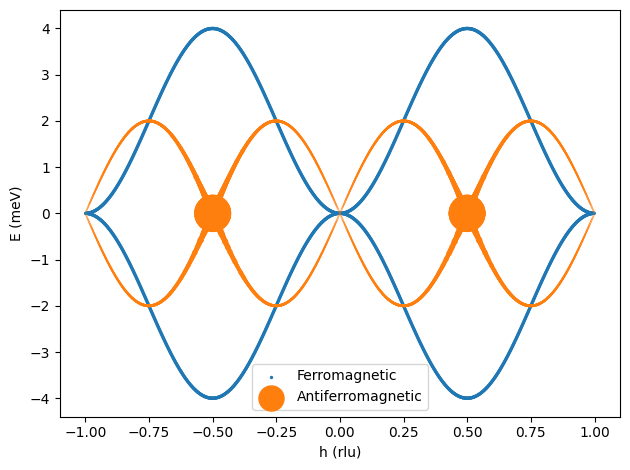

In [14]:
%run test_lswt.py

In [15]:
(hs, Es, ws), (sites, couplings) = ferro_data

In [16]:
sites, couplings

([{'S': 1.0,
   'Sdir': [0, 0, 1],
   'pos': [0, 0, 0],
   'u': array([1.+0.j, 0.+1.j, 0.+0.j]),
   'v': array([0., 0., 1.])}],
 [{'sites': [0, 0],
   'J': -1.0,
   'dist': [1, 0, 0],
   'J_real': array([[-1.,  0.,  0.],
          [ 0., -1.,  0.],
          [ 0.,  0., -1.]])}])

In [17]:
jnp.where(jnp.isnan(E))

(Array([], shape=(0,), dtype=int64), Array([], shape=(0,), dtype=int64))

In [18]:
E, w = model(Q_pts, jnp.array([-1, 0, 0.0]))
# assert ~jnp.isnan(E).any()
# assert ~jnp.isnan(w).any()

In [19]:
jnp.isnan(jnp.array(ws)).any()

Array(False, dtype=bool)

In [20]:
jnp.isnan(jnp.array(Es)).any()

Array(False, dtype=bool)

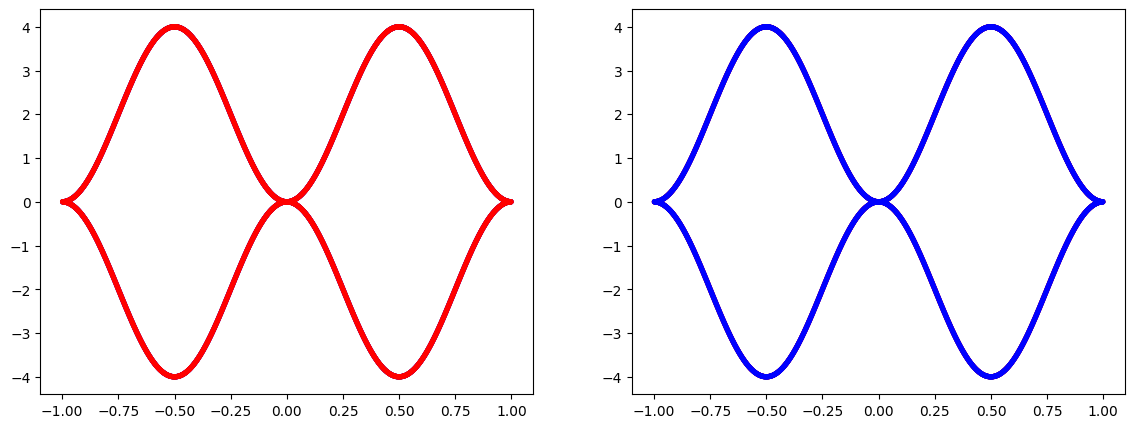

In [21]:
plt.subplots(1, 2, figsize=(14,5))
plt.subplot(121)
plt.scatter(hs, Es, ws, color='blue')

for _e, _w in zip(E.T, w.T):
    plt.scatter(Q_pts[:,0], _e, s=_w*weight_scale, color='red')

plt.subplot(122)
for _e, _w in zip(E.T, w.T):
    plt.scatter(Q_pts[:,0], _e, s=_w*weight_scale, color='red')
plt.scatter(hs, Es, ws, color='blue')


In [22]:
(hs, Es, ws), (sites, couplings) = anti_ferro_data

In [23]:
sites, couplings

([{'S': 1.0,
   'Sdir': [0, 0, 1],
   'pos': [0, 0, 0],
   'u': array([1.+0.j, 0.+1.j, 0.+0.j]),
   'v': array([0., 0., 1.])},
  {'S': 1.0,
   'Sdir': [0, 0, -1],
   'pos': [1, 0, 0],
   'u': array([-1.+0.j,  0.+1.j,  0.+0.j]),
   'v': array([ 0.,  0., -1.])}],
 [{'sites': [0, 1],
   'J': 1.0,
   'dist': [0, 0, 0],
   'J_real': array([[1., 0., 0.],
          [0., 1., 0.],
          [0., 0., 1.]])},
  {'sites': [1, 0],
   'J': 1.0,
   'dist': [2, 0, 0],
   'J_real': array([[1., 0., 0.],
          [0., 1., 0.],
          [0., 0., 1.]])}])

In [24]:

def model_antiferro(Q_vec, params):
    S_values = jnp.array([1.0, 1], dtype=float)
    S_directions = jnp.array([[0, 0, 1], [0,0,-1]], dtype=float)
    positions = jnp.array([[0,0,0], [1,0,0]], dtype=float)
    dist_vectors = jnp.array([[0,0,0], [2,0,0]], dtype=float)
    sites_i = jnp.array([0, 1])
    sites_j = jnp.array([1, 0])
    
    U, V = jax.vmap(get_u_v)(S_directions)
    
    J = params
    J_values = jnp.array([J, J], dtype=float)
    DMI_vectors = jnp.array([[0,0,0], [0,0,0]], dtype=float)
    gen_matrices = jnp.array([
        [
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
        [
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
    ], dtype=float)
    J_real = jax.vmap(get_J_real)(J_values, DMI_vectors, gen_matrices)
    # print(J_real, U, V)
    (E, w) = batched_by_q(Q_vec, S_values, U, V, positions, J_real, dist_vectors, sites_i, sites_j)
    # err.throw()
    
    return E, w

In [25]:
E, w = model_antiferro(Q_pts, (1, ))
assert ~jnp.isnan(E).any()
assert ~jnp.isnan(w).any()


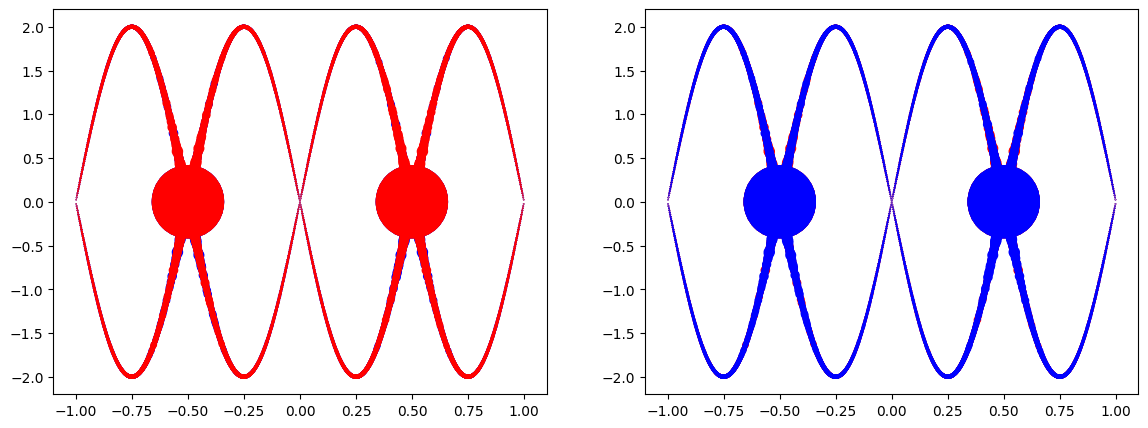

In [26]:
plt.subplots(1, 2, figsize=(14,5))
plt.subplot(121)
plt.scatter(hs, Es, ws, color='blue')
for _e, _w in zip(E.T, w.T):
    plt.scatter(Q_pts[:,0], _e, s=_w*weight_scale, color='red')

plt.subplot(122)
for _e, _w in zip(E.T, w.T):
    plt.scatter(Q_pts[:,0], _e, s=_w*weight_scale, color='red')
plt.scatter(hs, Es, ws, color='blue')


In [27]:
J_E, J_w = jax.jacobian(model, 1)(Q_pts, jnp.array([-1.0, 0.25, -0.06]))

In [28]:
E, w = model(Q_pts, jnp.array([-1.0, 0.25, -0.06]))

In [29]:
J_E.shape, J_w.shape

((1024, 2, 3), (1024, 2, 3))

In [30]:
J_E

Array([[[ 0.00000000e+00, -4.89858720e-16, -2.00000000e+00],
        [ 0.00000000e+00, -4.89858720e-16,  2.00000000e+00]],

       [[-1.50890883e-04, -2.45670666e-02, -2.00000000e+00],
        [ 1.50890883e-04, -2.45670666e-02,  2.00000000e+00]],

       [[-6.03540763e-04, -4.91304263e-02, -2.00000000e+00],
        [ 6.03540763e-04, -4.91304263e-02,  2.00000000e+00]],

       ...,

       [[-6.03540763e-04,  4.91304263e-02, -2.00000000e+00],
        [ 6.03540763e-04,  4.91304263e-02,  2.00000000e+00]],

       [[-1.50890883e-04,  2.45670666e-02, -2.00000000e+00],
        [ 1.50890883e-04,  2.45670666e-02,  2.00000000e+00]],

       [[ 0.00000000e+00,  4.89858720e-16, -2.00000000e+00],
        [ 0.00000000e+00,  4.89858720e-16,  2.00000000e+00]]],      dtype=float64)

In [31]:
J_w

Array([[[0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.]]], dtype=float64)

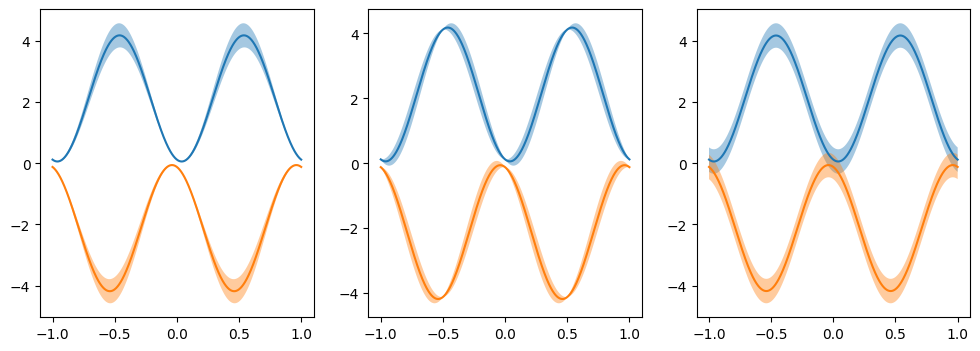

In [32]:
plt.subplots(1,3,figsize=(12,4))
for i, param_stds in enumerate([[0.1, 0.0, 0.0], [0, 0.2, 0], [0, 0, 0.2]]):
    plt.subplot(1,3,i+1)
    param_stds = jnp.array(param_stds)

    cov = jnp.diag(param_stds**2)
    var = jax.vmap(jax.vmap(lambda j: j @ cov @ j.T))(J_E)
    std = jnp.sqrt(var)

    for _E, s in zip(E.T, std.T):
        plt.plot(Q_pts[:,0], _E)
        plt.fill_between(Q_pts[:,0], _E-s, _E+s, alpha=0.4)



In [33]:
def kernel_cov(q, E):
    cov = jnp.array([
        [1e-3, 0.],
        [0., 0.1],
    ])
    return cov

def gaussian(q0, q1, E0, E1):
    cov = kernel_cov(q1[0], E1)
    r = jnp.array([(q1-q0)[0], E1-E0])
    ld = jnp.linalg.slogdet(cov)[1]
    norm = jnp.exp(-0.5*ld) / (2 * jnp.pi)**2
    exp = jnp.exp(-0.5 * r @ jnp.linalg.inv(cov) @ r)
    return exp * norm

In [34]:
def calc_reso_curve(q, E, params, scale=0.1, grid_size=11):
    q_grid = q + jnp.array([jnp.linspace(-3,3,grid_size)*scale, jnp.zeros(grid_size), jnp.zeros(grid_size)]).T
    E_grid, I_grid = model(q_grid, params)
    kernel_evals = jax.vmap(lambda _E: jax.vmap(gaussian, (0, None, 0, None))(q_grid, q, _E, E), 1)(E_grid).T
    delta_q = q_grid[1,0] - q_grid[0,0]
    # return (kernel_evals * I_grid * delta_q).sum()
    # J = jnp.diagonal(jax.jacobian(lambda q, p: calc_curve(q,p)[0], 0)(q_grid, params), axis1=0, axis2=2)
    # w = delta_q # jnp.sqrt(delta_q**2 + (delta_q*J.T)**2)
    # y = (kernel_evals * I_grid * w).sum()
    integrand = kernel_evals * I_grid
    integral = delta_q * ( 0.5 * (integrand[0] + integrand[-1]) + integrand[1:-1].sum()).sum()
    return integral

In [35]:
params = jnp.array([-1, 0.25, -0.06])

In [36]:
calc_reso_curve(Q_pts[0], 2., params)

Array(3.80556047e-06, dtype=float64)

In [37]:
X = jnp.array([[_q, 0, 0, _e] for _q in jnp.linspace(-1,1,35) for _e in jnp.linspace(-6,6,31)])

In [38]:
y = jax.vmap(calc_reso_curve, (0, 0, None))(X[:,:3], X[:,-1], params)
y.shape

(1085,)

Text(0, 0.5, 'E')

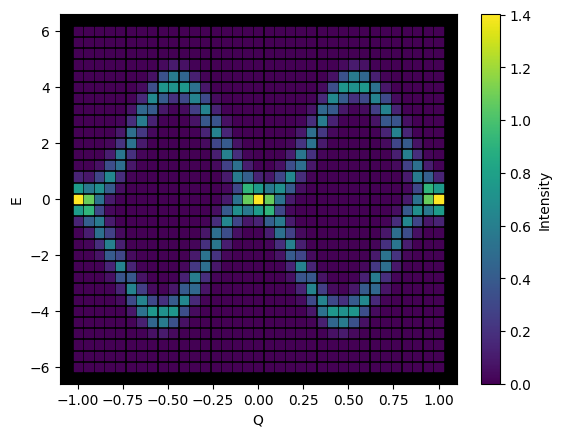

In [39]:
plt.scatter(X[:,0], X[:,-1], c=y, marker='s')
plt.gca().set_facecolor('black')
plt.colorbar(label='Intensity')
plt.xlabel('Q')
plt.ylabel('E')

In [40]:
compute_jac = jax.jit(jax.jacobian(lambda p, _X: jax.vmap(calc_reso_curve, (0,0,None))(*_X.T, p), 0))

In [41]:
intensity_func = jax.vmap(calc_reso_curve, (0, 0, None))

In [42]:
y = intensity_func(X[:,:3], X[:,-1], params)

In [43]:
jac = jax.jit(lambda x, p: jax.jacobian(intensity_func, argnums=2)(x[:,:3], x[:,-1], p))

In [44]:
J = jac(X[:10], params)

In [45]:
J = jac(X, params)

In [46]:
jnp.isnan(J).any()

Array(False, dtype=bool)

In [48]:
J_curve = jax.jacobian(lambda p: model(Q_pts, p)[0])(params)

In [49]:
Es, _ = model(Q_pts, params)

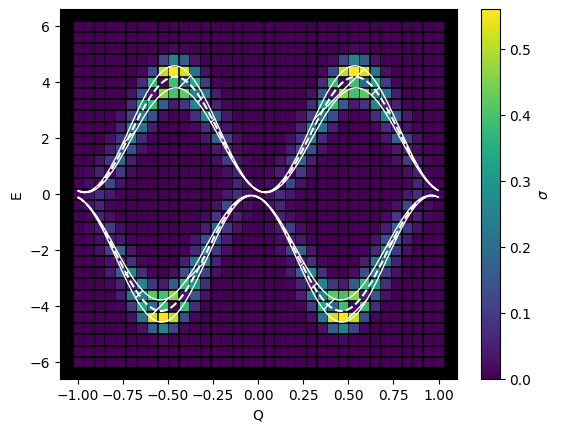

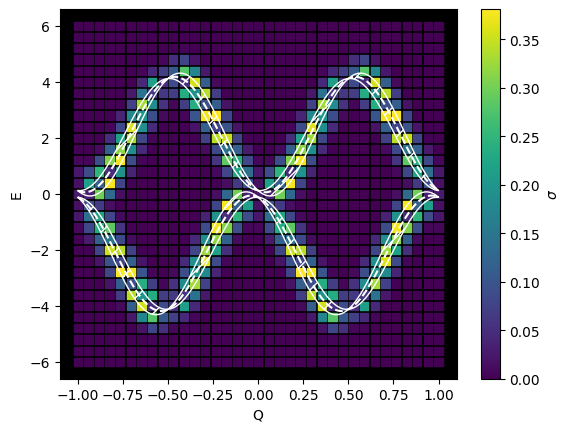

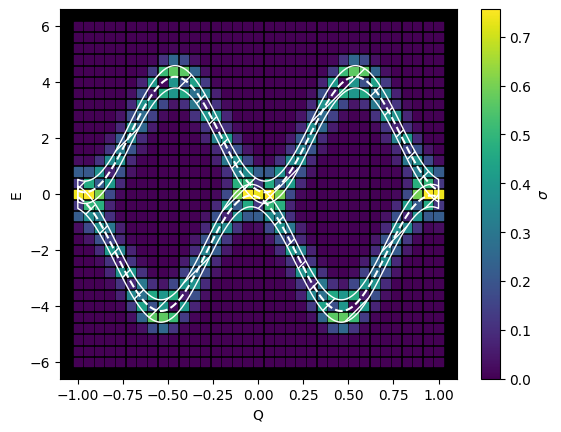

In [60]:
# plt.subplots(1,3,figsize=(12,3))
for i, param_stds in enumerate([[0.1, 0.0, 0.0], [0, 0.2, 0], [0, 0, 0.2]]):
    # plt.subplot(1,3,i+1)
    param_stds = jnp.array(param_stds)
    cov = jnp.diag(param_stds**2)

    var = jax.vmap(lambda j: j @ cov @ j)(J)
    std = jnp.sqrt(var)
    plt.scatter(X[:,0], X[:,-1], c=std, marker='s')
    plt.gca().set_facecolor('black')
    plt.colorbar(label=r'$\sigma$')
    plt.xlabel('Q')
    plt.ylabel('E')

    var = jax.vmap(jax.vmap(lambda j: j @ cov @ j.T))(J_curve)
    std = jnp.sqrt(var)
    for _E, s in zip(E.T, std.T):
        plt.plot(Q_pts[:,0], _E, color='white', linestyle='--')
        plt.fill_between(Q_pts[:,0], _E-s, _E+s, edgecolor='white', facecolor='none', hatch='/')
    plt.show()